17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Name: Shalini A
Register No: 24BAD409

Training samples: 25000
Testing samples: 25000
Positive samples: 12500
Negative samples: 12500

Padded training shape: (25000, 200)
Padded testing shape: (25000, 200)
Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)

Embedding Output Shape: (None, 200, 64)

LSTM MODEL SUMMARY


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 141ms/step - accuracy: 0.5559 - loss: 0.6803 - val_accuracy: 0.5810 - val_loss: 0.6558
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.6912 - loss: 0.5563 - val_accuracy: 0.8296 - val_loss: 0.4299
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.7675 - loss: 0.4875 - val_accuracy: 0.5752 - val_loss: 0.8161
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 0.7537 - loss: 0.4745 - val_accuracy: 0.8192 - val_loss: 0.4571
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.7832 - loss: 0.4668 - val_accuracy: 0.8014 - val_loss: 0.4950

Final Training Accuracy: 0.7832000255584717
Final Validation Accuracy: 0.8014000058174133
Final Training Loss: 0.466793030500412
Final Validation Loss: 0.49503231048583984


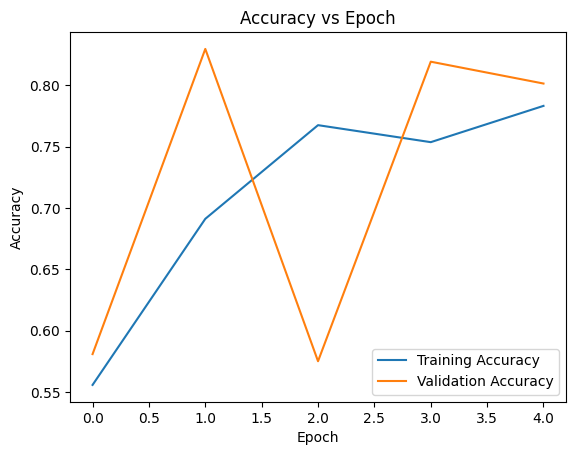

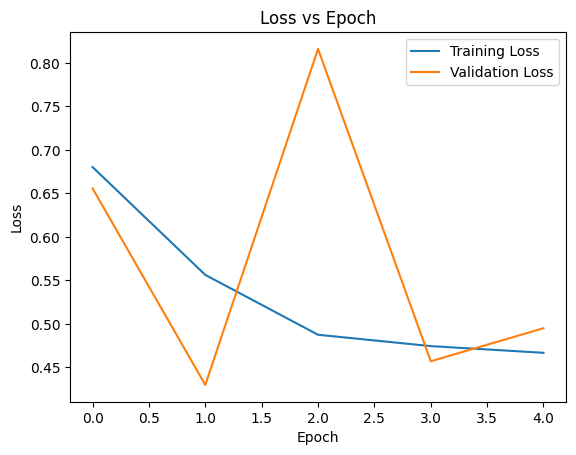

782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7936 - loss: 0.5117

Test Loss: 0.5116519331932068
Test Accuracy: 0.7936000227928162
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step

Accuracy: 0.7936
Precision: 0.7680788897005113
Recall: 0.8412
F1 Score: 0.8029782359679267


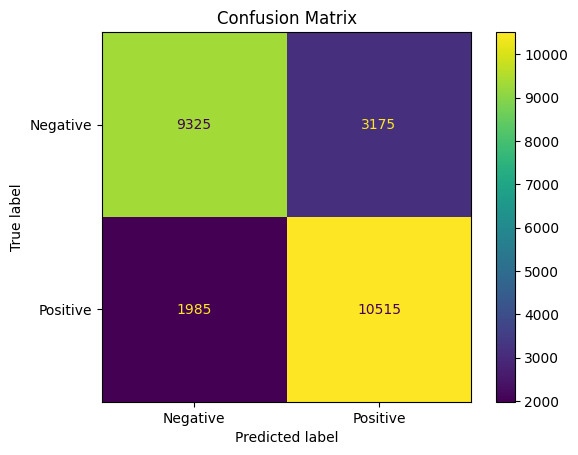

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Review: This movie was excellent and amazing. I really enjoyed it.
Predicted Sentiment: Positive
Probability: 0.6467124

Review: This movie was boring and terrible. I did not enjoy it.
Predicted Sentiment: Negative
Probability: 0.12936325


In [1]:
# LSTM SENTIMENT ANALYSIS USING IMDB DATASET
# Name: Shalini A
# Register No: 24BAD409

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# PART A: DATASET PREPARATION AND TEXT PREPROCESSING
# =========================================================
# Load IMDB dataset
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Name: Shalini A")
print("Register No: 24BAD409")
print("\nTraining samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Positive samples:", np.sum(y_train == 1))
print("Negative samples:", np.sum(y_train == 0))

# Sequence padding
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')
print("\nPadded training shape:", x_train.shape)
print("Padded testing shape:", x_test.shape)

# Validation data
x_val = x_train[:5000]
y_val = y_train[:5000]
x_train_new = x_train[5000:]
y_train_new = y_train[5000:]
print("Training data:", x_train_new.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)


# =========================================================
# PART B: EMBEDDING GENERATION
# =========================================================

embedding_dim = 64
embedding_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length)
])
embedding_model.build(input_shape=(None, max_length))
print("\nEmbedding Output Shape:",
      embedding_model.output_shape)

# =========================================================
# PART C: IMPLEMENTING LSTM MODEL
# =========================================================

model = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(64),
    Dense(1, activation='sigmoid')])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
print("\nLSTM MODEL SUMMARY")
model.summary()


# =========================================================
# PART D: MODEL TRAINING
# =========================================================
history = model.fit(
    x_train_new,
    y_train_new,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val))

# =========================================================
# TRAINING RESULTS
# =========================================================

print("\nFinal Training Accuracy:",
      history.history['accuracy'][-1])
print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])
print("Final Training Loss:",
      history.history['loss'][-1])
print("Final Validation Loss:",
      history.history['val_loss'][-1])


# =========================================================
# ACCURACY VS EPOCH
# =========================================================
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

# =========================================================
# LOSS VS EPOCH
# =========================================================

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()


# =========================================================
# TEST DATA EVALUATION
# =========================================================
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# =========================================================
# PREDICTION
# =========================================================

y_probability = model.predict(x_test)
y_pred = (y_probability > 0.5).astype(int).flatten()
print("\nAccuracy:",
      accuracy_score(y_test, y_pred))
print("Precision:",
      precision_score(y_test, y_pred))
print("Recall:",
      recall_score(y_test, y_pred))
print("F1 Score:",
      f1_score(y_test, y_pred))


# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# SAMPLE SENTIMENT PREDICTION
# =========================================================
word_index = imdb.get_word_index()
def encode_review(review):
    words = review.lower().split()
    sequence = []

    for word in words:
        word = re.sub(r'[^a-zA-Z]', '', word)
        index = word_index.get(word, 2) + 3
        if index < vocab_size:
            sequence.append(index)
        else:
            sequence.append(2)
    return pad_sequences([sequence], maxlen=max_length, padding='post')
reviews = [
    "This movie was excellent and amazing. I really enjoyed it.",
    "This movie was boring and terrible. I did not enjoy it."]
for review in reviews:
    sequence = encode_review(review)
    prediction = model.predict(sequence, verbose=0)[0][0]
    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)
    print("Probability:", prediction)